In [1]:
# !pip install pandas numpy sklearn seaborn
import pandas as pd

In [6]:
# %pip install pandas
# import pandas as pd
# print(pd.__version__)

Note: you may need to restart the kernel to use updated packages.


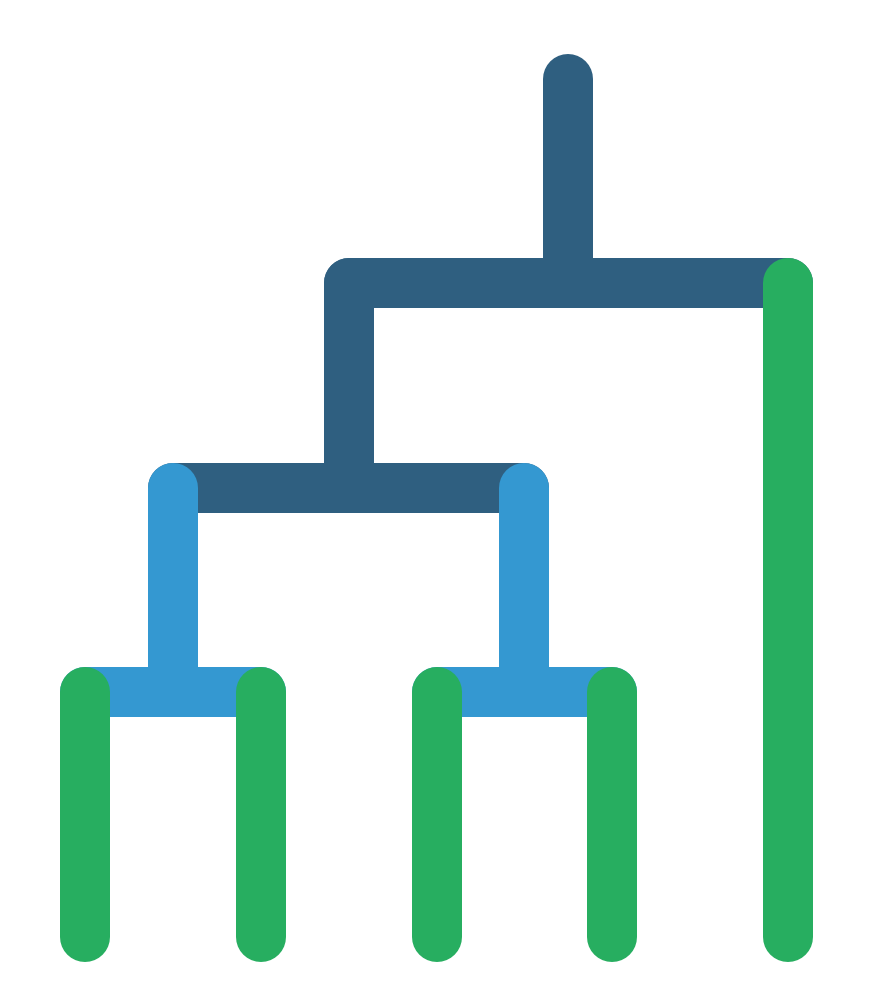

In [2]:
%pip install networkx matplotlib
import random
import networkx as nx
import matplotlib.pyplot as plt

def random_binary_tree_styled(n_leaves=10, seed=12, highlight=True):
    """Generate a random bifurcating tree with NetworkX and render in a similar style."""
    rng = random.Random(seed)

    # Build a random rooted binary tree by repeatedly merging two active nodes.
    rooted = nx.DiGraph()
    leaves = [f"L{i}" for i in range(n_leaves)]
    rooted.add_nodes_from(leaves)
    active = leaves[:]
    next_id = 0

    while len(active) > 1:
        a, b = rng.sample(active, 2)
        active.remove(a)
        active.remove(b)
        p = f"I{next_id}"
        next_id += 1
        rooted.add_node(p)
        rooted.add_edge(p, a)
        rooted.add_edge(p, b)
        # Random child order for varied shapes
        if rng.random() < 0.5:
            rooted.remove_edge(p, a)
            rooted.remove_edge(p, b)
            rooted.add_edge(p, b)
            rooted.add_edge(p, a)
        active.append(p)

    root = active[0]

    # Undirected NetworkX tree version (if you need standard tree algorithms).
    T = rooted.to_undirected()

    children = {u: list(rooted.successors(u)) for u in rooted.nodes()}
    depth = {root: 0}
    for u in nx.topological_sort(rooted):
        for v in children[u]:
            depth[v] = depth[u] + 1

    # Compact hierarchical x positions: leaves left->right, internals centered.
    x = {}
    leaf_order = [n for n in nx.dfs_preorder_nodes(rooted, source=root) if not children[n]]
    for i, leaf in enumerate(leaf_order):
        x[leaf] = i

    def assign_internal_x(u):
        ch = children[u]
        if not ch:
            return x[u]
        vals = [assign_internal_x(v) for v in ch]
        x[u] = sum(vals) / len(vals)
        return x[u]

    assign_internal_x(root)
    max_x = max(x.values()) if x else 1
    x = {k: 0.08 + 0.84 * (v / max_x if max_x else 0.5) for k, v in x.items()}

    max_depth = max(depth.values()) if depth else 1
    y = {k: 0.92 - 0.60 * (depth[k] / max_depth if max_depth else 0) for k in depth}
    tip_y = 0.08

    # Highlight one random internal clade in magenta.
    highlight_edges = set()
    highlight_nodes = set()
    if highlight:
        internal = [u for u in rooted.nodes() if children[u]]
        if internal:
            h = rng.choice(internal)
            stack = [h]
            while stack:
                u = stack.pop()
                highlight_nodes.add(u)
                for v in children[u]:
                    highlight_edges.add((u, v))
                    stack.append(v)

    blue_dark = "#2f5f80"
    blue_light = "#3498d1"
    magenta = "#c13b9b"
    orange = "#e67e22"
    green = "#27ae60"
    lw = 20

    fig, ax = plt.subplots(figsize=(6, 7), dpi=180)

    def seg(x1, y1, x2, y2, c):
        ax.plot(
            [x1, x2], [y1, y2],
            color=c, lw=lw, solid_capstyle="round", solid_joinstyle="round"
        )

    # Draw each internal node as a classic bifurcation: trunk, bar, two drops.
    for u in nx.topological_sort(rooted):
        ch = children[u]
        if not ch:
            continue

        y_split = sum(y[v] for v in ch) / len(ch)
        x_left, x_right = sorted([x[ch[0]], x[ch[1]]])
        trunk_color = blue_dark if depth[u] <= 1 else blue_light

        seg(x[u], y[u], x[u], y_split, trunk_color)
        seg(x_left, y_split, x_right, y_split, trunk_color)

        for v in ch:
            c = green if (u, v) in highlight_edges else blue_light
            seg(x[v], y_split, x[v], y[v], c)

    # Extend every terminal branch to the same depth (ultrametric-style tips).
    for leaf in leaves:
        leaf_color = green if leaf in highlight_nodes else blue_light
        seg(x[leaf], y[leaf], x[leaf], tip_y, leaf_color)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.03, 0.98)
    ax.axis("off")
    plt.show()

    return T, rooted

# Example: each run with a new seed gives a different random bifurcating tree
T, rooted = random_binary_tree_styled(n_leaves=5, seed=100, highlight=True)

In [3]:
# T, rooted = random_binary_tree_styled(n_leaves=5, seed=12, highlight=True)

In [57]:
import re
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

def parse_newick_to_digraph(newick_text):
    """Parse Newick with NHX annotations into a rooted DiGraph (parent -> child)."""
    s = newick_text.strip()
    n = len(s)
    i = 0
    auto_id = [0]
    G = nx.DiGraph()

    def make_internal_name():
        auto_id[0] += 1
        return f"anc_auto_{auto_id[0]}"

    def unique_name(name):
        if name not in G:
            return name
        k = 1
        while f"{name}_{k}" in G:
            k += 1
        return f"{name}_{k}"

    def parse_nhx_fields(raw):
        attrs = {}
        text = raw.strip()
        if text.startswith("&&NHX:"):
            text = text[len("&&NHX:"):]
        for part in text.split(":"):
            if "=" in part:
                key, value = part.split("=", 1)
                attrs[key.strip()] = value.strip()
        return attrs

    def parse_label_length_annotations():
        nonlocal i
        # Label can be empty for internal nodes.
        start = i
        while i < n and s[i] not in ":,();[]":
            i += 1
        label = s[start:i].strip()

        # Optional branch length after ':'
        branch_length = None
        if i < n and s[i] == ":":
            i += 1
            start_len = i
            while i < n and s[i] not in ",();[]":
                i += 1
            raw_len = s[start_len:i].strip()
            if raw_len:
                try:
                    branch_length = float(raw_len)
                except ValueError:
                    branch_length = None

        # Optional annotations, e.g. [&&NHX:mutation=...:reads=3]
        ann = {}
        while i < n and s[i] == "[":
            i += 1
            start_ann = i
            while i < n and s[i] != "]":
                i += 1
            raw_ann = s[start_ann:i]
            if i < n and s[i] == "]":
                i += 1
            ann.update(parse_nhx_fields(raw_ann))

        return label, branch_length, ann

    def parse_subtree():
        nonlocal i
        if i < n and s[i] == "(":
            i += 1
            children = [parse_subtree()]
            while i < n and s[i] == ",":
                i += 1
                children.append(parse_subtree())
            if i >= n or s[i] != ")":
                raise ValueError("Malformed Newick: missing ')' ")
            i += 1

            label, branch_length, ann = parse_label_length_annotations()
            if not label:
                label = make_internal_name()
            label = unique_name(label)
            G.add_node(label)
            if branch_length is not None:
                G.nodes[label]["branch_length"] = branch_length
            G.nodes[label].update(ann)
            for c in children:
                G.add_edge(label, c)
            return label

        label, branch_length, ann = parse_label_length_annotations()
        if not label:
            label = make_internal_name()
        label = unique_name(label)
        G.add_node(label)
        if branch_length is not None:
            G.nodes[label]["branch_length"] = branch_length
        G.nodes[label].update(ann)
        return label

    root = parse_subtree()
    while i < n and s[i] in " ;\t\n\r":
        i += 1
    if i < n:
        raise ValueError(f"Malformed Newick: unexpected trailing content near index {i}")

    return G, root

def draw_lineage_tree_from_newick(newick_path, cmap, newick_text=None, colorbar_label="Subtree frequency"):
    """Render lineage tree with frequency-colored branches and mutation labels."""
    if newick_text is None:
        newick_text = Path(newick_path).read_text().strip()
    rooted, root = parse_newick_to_digraph(newick_text)

    children = {u: list(rooted.successors(u)) for u in rooted.nodes()}
    leaves = [u for u in rooted.nodes() if len(children[u]) == 0]

    # Fold the unmutated residual (ref / H0000 / ROOT) into the root.
    # Keep its reads for frequency, but do not draw a separate tip.
    ref_nodes = {
        v for v in children.get(root, [])
        if not children[v] and not rooted.nodes[v].get("mutation")
    }
    vis_children = {u: [v for v in ch if v not in ref_nodes] for u, ch in children.items()}
    vis_leaves = [u for u in leaves if u not in ref_nodes]

    # Depth from root for vertical layout.
    depth = {root: 0}
    for u in nx.topological_sort(rooted):
        for v in children[u]:
            depth[v] = depth[u] + 1

    # Leaf-driven x layout; internal nodes centered on descendants.
    x = {}
    leaf_order = [u for u in nx.dfs_preorder_nodes(rooted, source=root) if u in vis_leaves]
    for idx, leaf in enumerate(leaf_order):
        x[leaf] = idx

    def assign_x(u):
        ch = vis_children[u]
        if not ch:
            return x[u]
        vals = [assign_x(v) for v in ch]
        x[u] = sum(vals) / len(vals)
        return x[u]

    if vis_leaves:
        assign_x(root)
    else:
        x[root] = 0
    max_x = max(x.values()) if x else 1
    x = {k: 0.08 + 0.84 * (v / max_x if max_x else 0.5) for k, v in x.items()}

    # Equal-depth terminal extensions for cleaner comparison.
    max_depth = max(depth.values()) if depth else 1
    y = {k: 0.94 - 0.78 * (depth[k] / max_depth if max_depth else 0) for k in depth}
    tip_y = 0.10

    # Read support from NHX reads=... or fallback label suffix _nNN.
    read_count = {}
    for node in rooted.nodes():
        def as_number(val):
            if val is None:
                return None
            try:
                return float(val)
            except (TypeError, ValueError):
                return None

        n = as_number(rooted.nodes[node].get("reads"))
        if n is None:
            n = as_number(rooted.nodes[node].get("freq"))
        if n is None:
            m = re.search(r"_n(\d+)$", node)
            n = int(m.group(1)) if m else 0.0
        read_count[node] = n

    # Subtree totals, then frequency = fraction of the root total.
    subtree_reads = {}
    for u in reversed(list(nx.topological_sort(rooted))):
        subtotal = read_count.get(u, 0) + sum(subtree_reads[v] for v in children[u])
        subtree_reads[u] = subtotal

    total = subtree_reads.get(root, 0) or 1.0
    subtree_freq = {u: subtree_reads[u] / total for u in subtree_reads}

    edge_support = {(u, v): subtree_freq[v] for u, v in rooted.edges()}
    norm = Normalize(vmin=0.0, vmax=1.0)
    cmap = plt.get_cmap(cmap)

    lw = 8
    fig, ax = plt.subplots(figsize=(12, 13), dpi=180)

    def edge_color(u, v):
        return cmap(norm(edge_support[(u, v)]))

    def seg(x1, y1, x2, y2, color):
        ax.plot(
            [x1, x2], [y1, y2],
            color=color, lw=lw, solid_capstyle="round", solid_joinstyle="round"
        )

    # Draw bifurcations and label mutations on parent->child branches.
    for u in nx.topological_sort(rooted):
        ch = vis_children[u]
        if not ch:
            continue

        y_split = sum(y[v] for v in ch) / len(ch)
        x_vals = sorted(x[v] for v in ch)

        # Color trunk/bar by aggregate support under this clade.
        clade_color = cmap(norm(subtree_freq[u]))
        seg(x[u], y[u], x[u], y_split, clade_color)
        seg(x_vals[0], y_split, x_vals[-1], y_split, clade_color)

        for v in ch:
            c = edge_color(u, v)
            seg(x[v], y_split, x[v], y[v], c)

            # Mutation belongs to child branch annotation in Newick/NHX.
            mut = rooted.nodes[v].get("mutation")
            if mut:
                xm = x[v] + 0.006
                ym = (y_split + y[v]) / 2 + 0.02
                ax.text(
                    xm, ym, mut,
                    fontsize=12, fontweight="bold", color="#1f2937",
                    va="bottom", ha="left",
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 0.6}
                )

    # Extend terminals to common tip depth using their incoming branch color.
    for leaf in vis_leaves:
        preds = list(rooted.predecessors(leaf))
        if preds:
            p = preds[0]
            c = edge_color(p, leaf)
        else:
            c = cmap(norm(subtree_freq.get(leaf, 0)))
        seg(x[leaf], y[leaf], x[leaf], tip_y, c)
        ax.text(x[leaf], tip_y - 0.02, leaf, ha="center", va="top", fontsize=9, rotation=35)

    ax.text(
        x[root], y[root] + 0.03, "Homoplasmy",
        ha="center", va="bottom", fontsize=12, fontweight="bold", color="#1f2937",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 0.6},
    )

    # Colorbar legend for read-count gradient.
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.02, shrink=0.38, aspect=18)
    cbar.set_label(colorbar_label, rotation=90)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.0, 1.08)
    ax.axis("off")
    plt.show()

    return rooted, root



In [58]:
import csv
import re
from collections import defaultdict

def clones_tsv_to_newick(clones_path):
    """Build a Newick/NHX tree from simulate_tree.py clones.tsv.

    variant_path is the root-to-node mutation chain. Internal clones keep
    residual frequency, so each such node also emits a tip (like H0000).
    """
    rows = []
    with open(clones_path) as fh:
        for row in csv.DictReader(fh, delimiter="\t"):
            path = tuple(v for v in row["variant_path"].split(",") if v)
            variant = "" if row["node_variant"] == "ROOT" else row["node_variant"]
            cid = row["clone_id"]
            name = "ref" if cid == "ref" else f"C{cid}"
            rows.append({
                "name": name,
                "variant": variant,
                "path": path,
                "freq": float(row["frequency"]),
            })

    by_path = {r["path"]: r for r in rows}
    children = defaultdict(list)
    for r in rows:
        if r["path"]:
            children[r["path"][:-1]].append(r["path"])

    def mut_pos(variant):
        m = re.match(r"m\.(\d+)", variant)
        return int(m.group(1)) if m else 0

    def nhx(mutation=None, freq=None):
        parts = []
        if mutation:
            parts.append(f"mutation={mutation}")
        if freq is not None:
            parts.append(f"freq={freq}")
        return f"[&&NHX:{':'.join(parts)}]" if parts else ""

    def rec(path):
        r = by_path[path]
        kids = sorted(children.get(path, []), key=lambda p: mut_pos(by_path[p]["variant"]))
        if not kids:
            return f"{r['name']}{nhx(r['variant'], r['freq'])}"
        parts = [rec(k) for k in kids]
        parts.append(f"{r['name']}{nhx(freq=r['freq'])}")
        return f"({','.join(parts)}){nhx(r['variant'], r['freq'])}"

    root_path = ()
    if root_path not in by_path:
        raise ValueError("clones.tsv is missing the ref/ROOT row")
    r = by_path[root_path]
    kids = sorted(children.get(root_path, []), key=lambda p: mut_pos(by_path[p]["variant"]))
    parts = [rec(k) for k in kids]
    parts.append(f"{r['name']}{nhx(freq=r['freq'])}")
    return f"({','.join(parts)})Germline{nhx(freq=r['freq'])};"





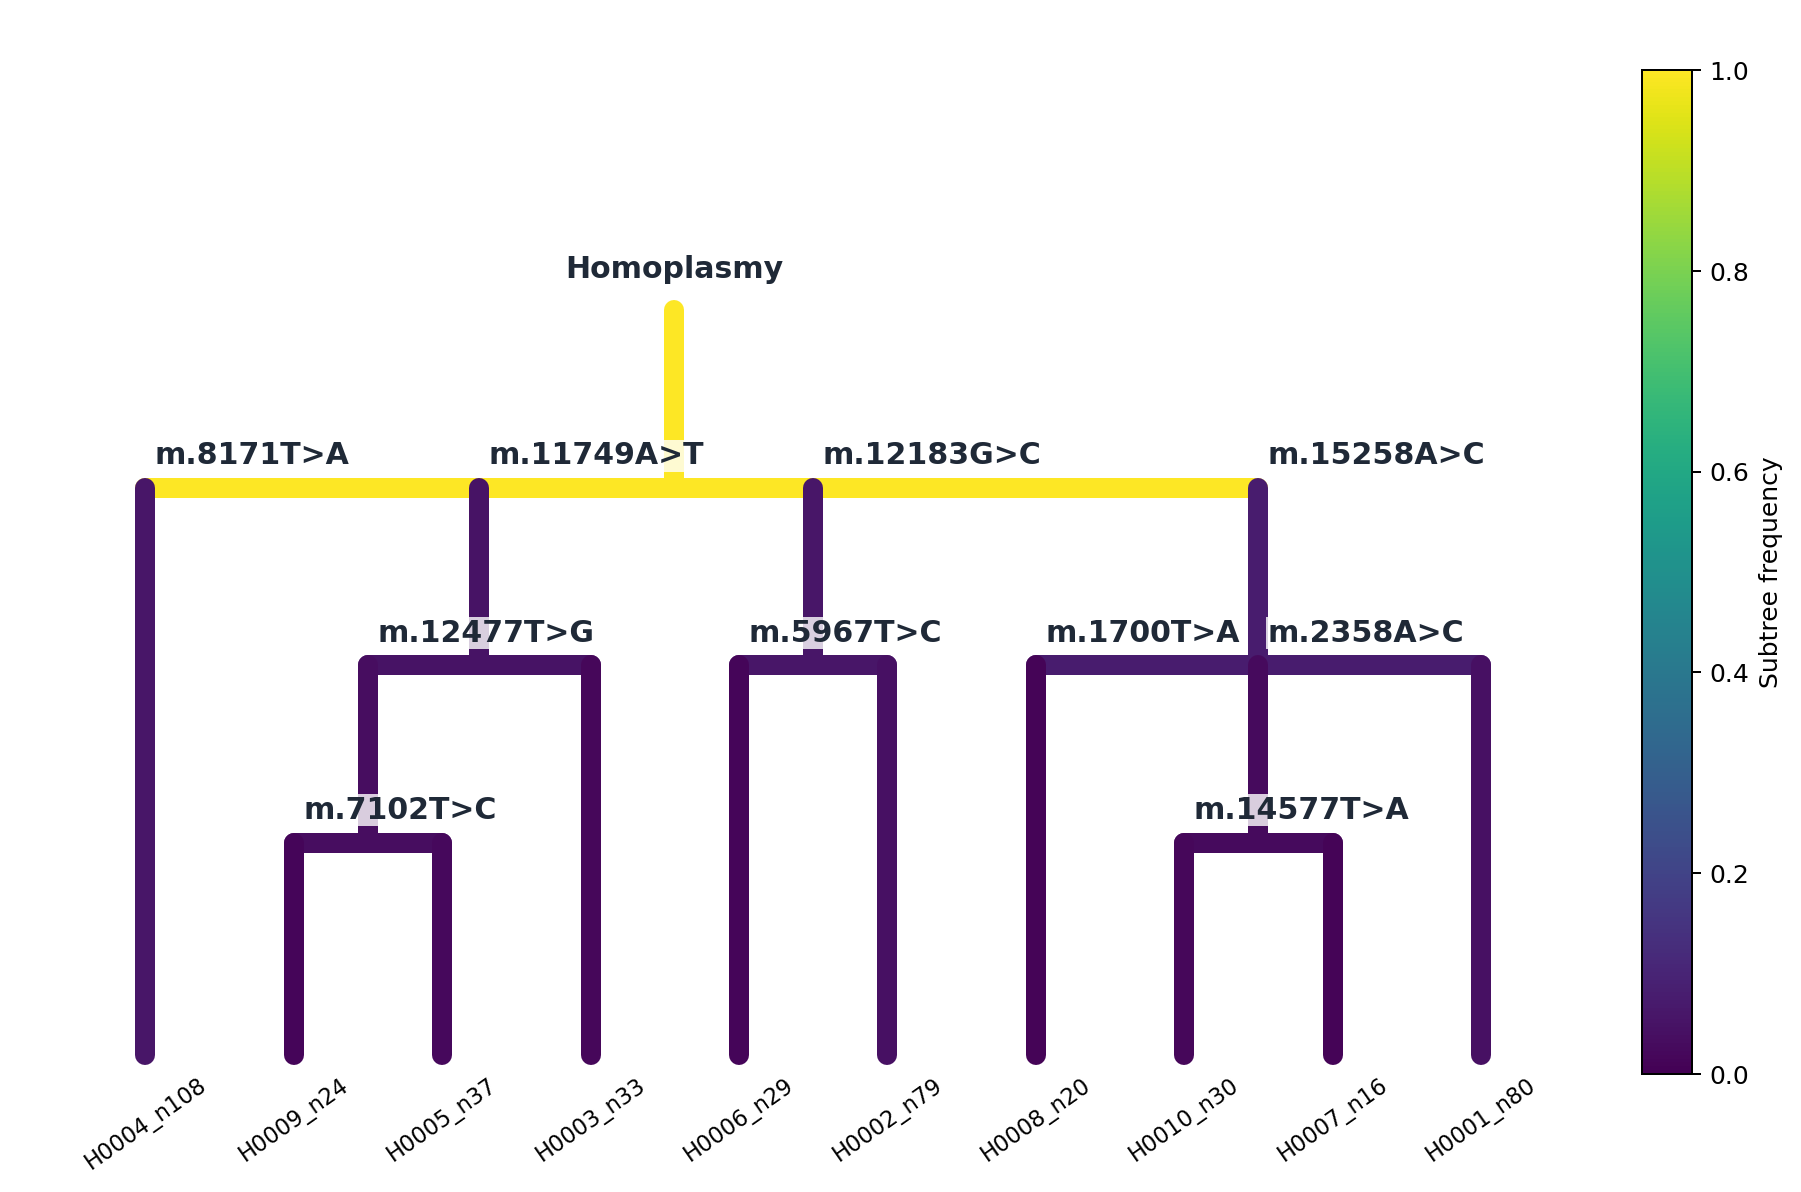

In [59]:
filename = "/Users/suhang/Analysis/Himito/lineage_eval/lineage_sim/tmp/simulation_ont_r10/seed1_mut10_depth1000/himito/sim_lineage.read_lineage.nwk"
rooted_nwk, root_nwk = draw_lineage_tree_from_newick(filename, "viridis")

(C6[&&NHX:mutation=m.8171T>A:freq=0.204988],((C7[&&NHX:mutation=m.7102T>C:freq=0.083752],C5[&&NHX:freq=0.020938])[&&NHX:mutation=m.12477T>G:freq=0.020938],C1[&&NHX:freq=0.026172])[&&NHX:mutation=m.11749A>T:freq=0.026172],(C8[&&NHX:mutation=m.5967T>C:freq=0.092953],C4[&&NHX:freq=0.023238])[&&NHX:mutation=m.12183G>C:freq=0.023238],(C3[&&NHX:mutation=m.1700T>A:freq=0.085773],(C10[&&NHX:mutation=m.14577T>A:freq=0.077275],C9[&&NHX:freq=0.019319])[&&NHX:mutation=m.2358A>C:freq=0.019319],C2[&&NHX:freq=0.045592])[&&NHX:mutation=m.15258A>C:freq=0.045592],ref[&&NHX:freq=0.32])Germline[&&NHX:freq=0.32];


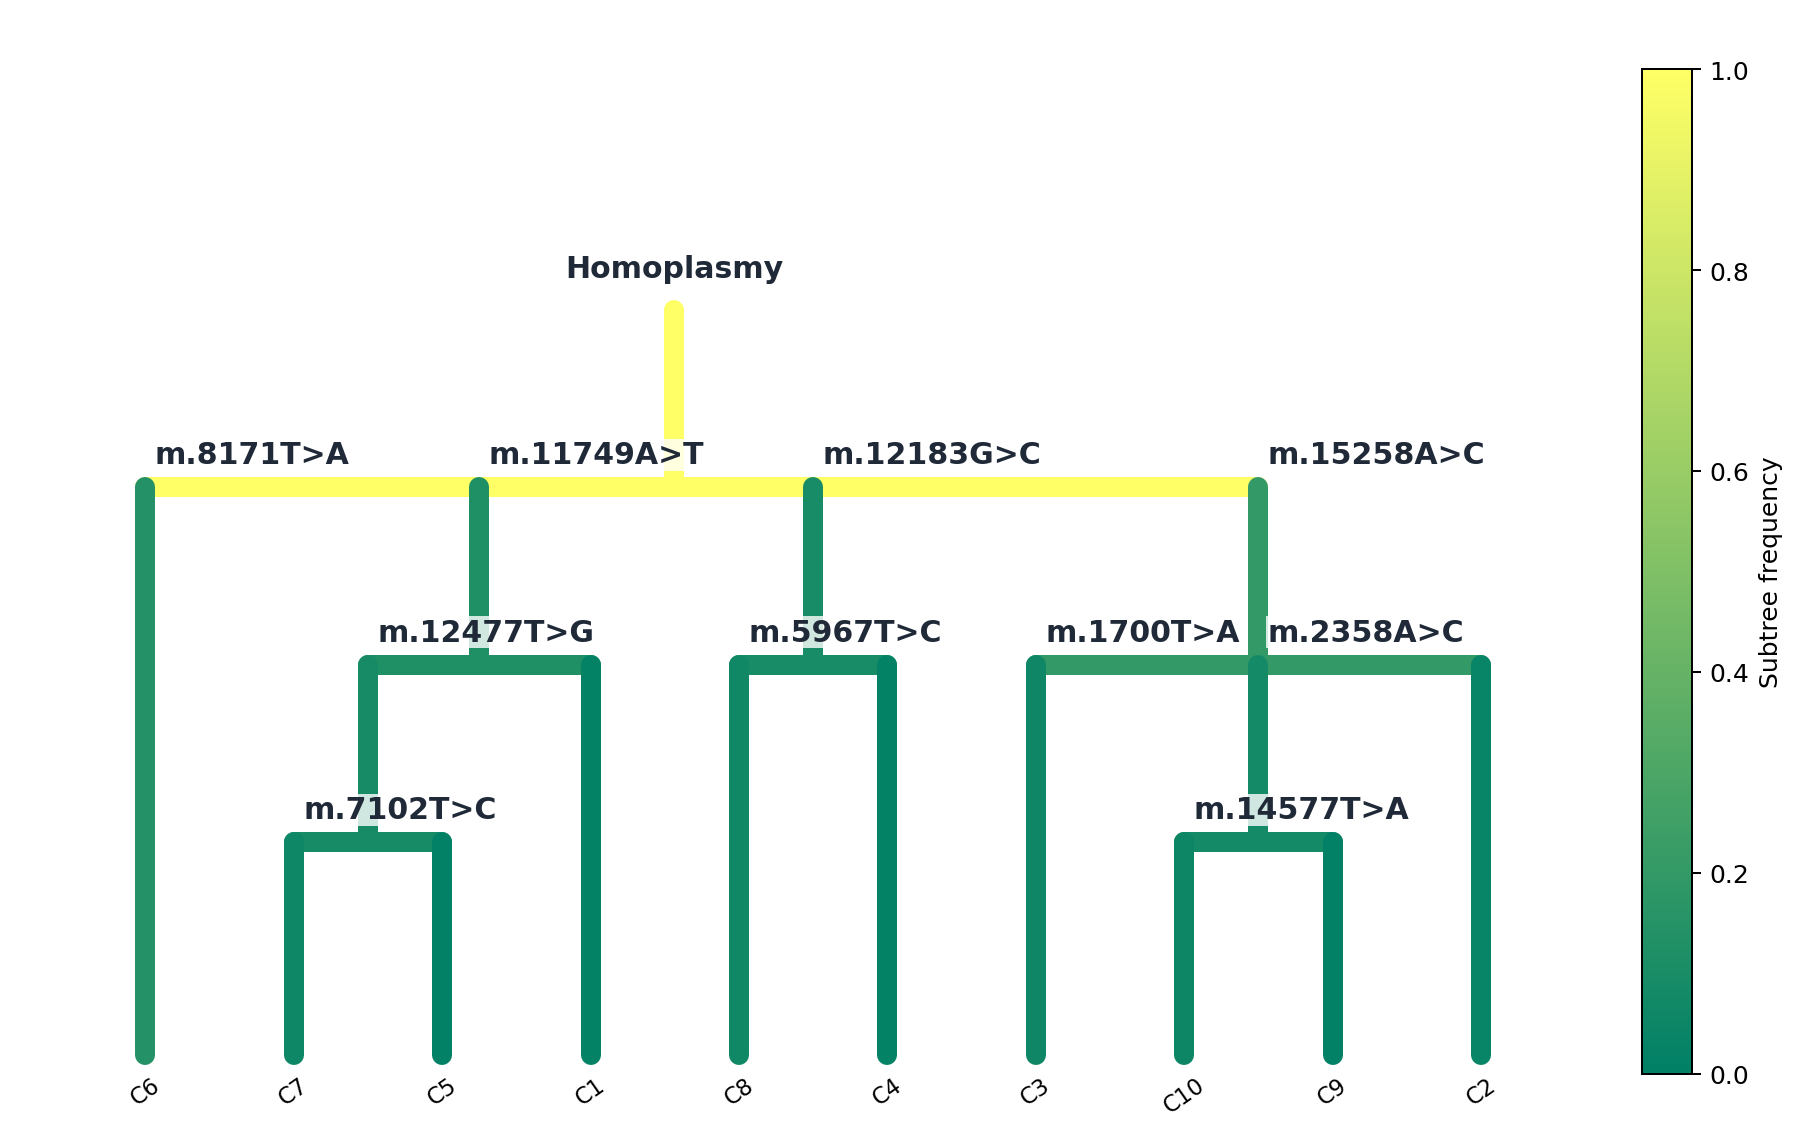

In [60]:
clones_path = "/Users/suhang/Analysis/Himito/lineage_eval/lineage_sim/tmp/simulation_ont_r10/seed1_mut10_depth1000/truth/clones.tsv"
truth_nwk = clones_tsv_to_newick(clones_path)
print(truth_nwk)
rooted_truth, root_truth = draw_lineage_tree_from_newick(
    None, "summer", newick_text=truth_nwk, colorbar_label="Subtree frequency",
)